# 2 Working with Real‐World Audio Signals

## 2.1 Loading the clean SOS signal

The file `imperfect_sos_cw_700_15_wpm.wav` was loaded successfully using `wavfile.read()`.  
The returned sampling rate `fs` gives the playback rate of the signal, while `x` contains the audio samples as a one-dimensional array.  
The audio widget allows direct playback of the signal for inspection in the time and audio domains.

In [1]:
import os
from scipy.io import wavfile

fs, x = wavfile.read(os.path.join('data', 'imperfect_sos_cw_700_15_wpm.wav'))
import IPython.display as ipd
ipd.display(ipd.Audio(data=x, rate=fs))


## 2.2 Plot of the clean signal

The full signal plot shows a sequence of bursts separated by quiet intervals.  
The burst pattern is three short bursts, followed by three longer bursts, followed by three short bursts again, which matches the Morse code pattern for S.O.S.  
Since the plot contains a large number of samples, it is useful for identifying the overall structure of the signal, but not for inspecting the detailed waveform shape.

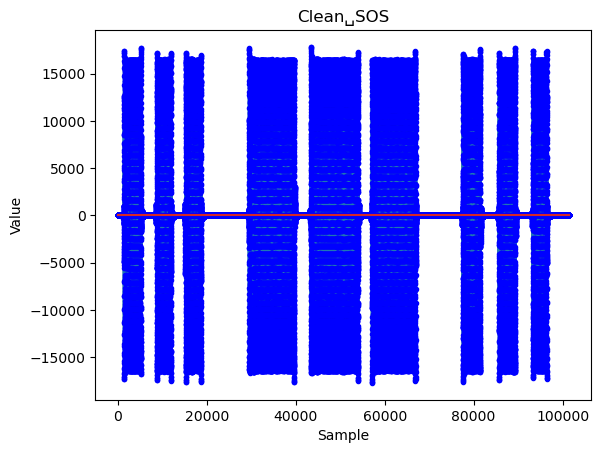

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.stem(x,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Clean␣SOS')
plt.show()

## 2.3 Zoomed view of the clean signal

When a smaller range of samples is plotted, the waveform becomes much clearer.  
In this zoomed region, the signal is approximately sinusoidal, which is consistent with a tone-based Morse code transmission.  
This close-up view makes it easier to see the oscillatory structure that is hidden in the full-length plot.

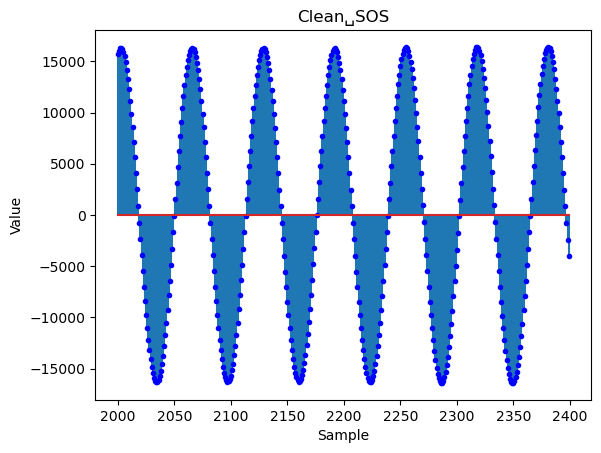

In [3]:
plt.figure()
t = range(2000,2400)
plt.stem(t,x[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Clean␣SOS')
plt.show()

# 3 Noisy Audio Signal

## 3.1

In [4]:
fs, x = wavfile.read(os.path.join('data', 'noisy_sos_cw_700_15_wpm.wav'))
import IPython.display as ipd
ipd.display(ipd.Audio(data=x, rate=fs))


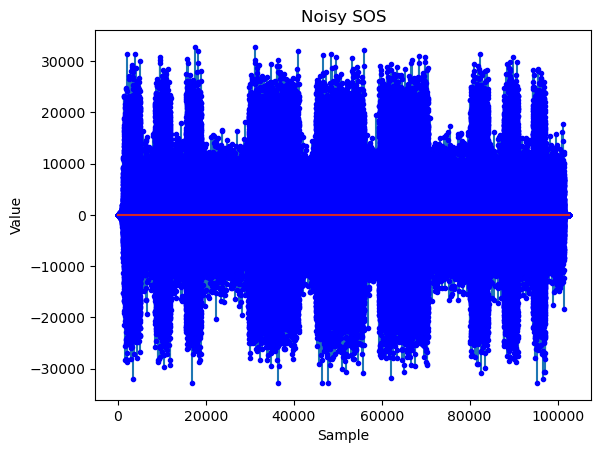

In [5]:
plt.figure()
plt.stem(x,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Noisy SOS')
plt.show()

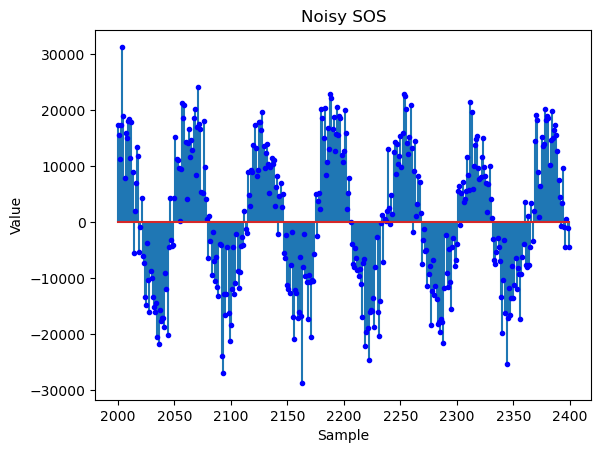

In [6]:
plt.figure()
t = range(2000,2400)
plt.stem(t,x[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Noisy SOS')
plt.show()

## 3.2

Compared to the signal in section 2, although it also looks similar to a sine wave, this one has more irregularities. The general shape of a sine wave in this graph contains more noise making it fluctuate more. In the sound of this you can hear background noise compared to the clean sound of section 2.

# 4 Moving Average Filter

## 4.1 Impulse response of the moving average filter

To implement a moving average over a window of length \(n=5\), the impulse response is chosen as:

In [7]:
import numpy as np

n=5
h= np.ones(n)/n
#h is a moving average of MOVING AVERAGVE OF SAMPLES

## 4.2

In [8]:
from scipy import signal
y = signal.convolve(x,h)

## 4.3 Effect of filtering with the moving average filter

After convolution with the moving average filter, the signal becomes smoother and the random noise is reduced. In the plot, the waveform is less jagged than the original noisy signal, which makes the Morse bursts easier to distinguish. In the audio playback, the tone is clearer and less harsh, although some noise is still present. The filter improves intelligibility, but it also slightly smooths the signal transitions.

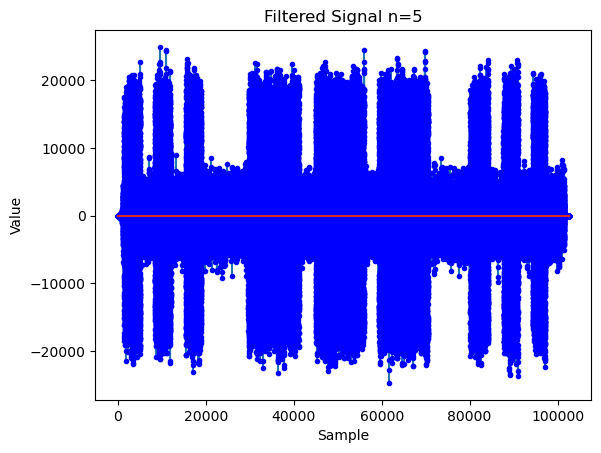

In [9]:
plt.figure()
plt.stem(y,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered Signal n=5')
plt.show()

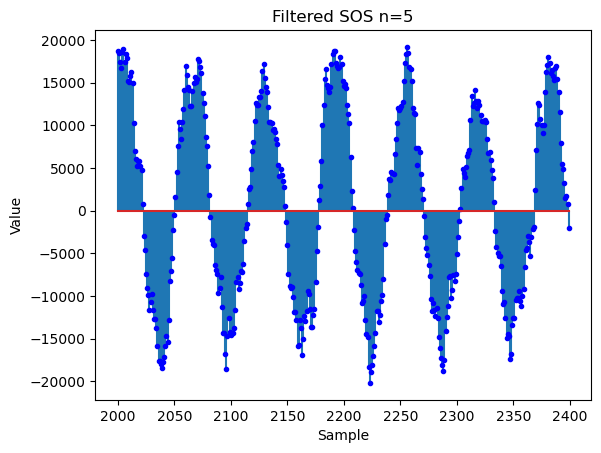

In [10]:
plt.figure()
t = range(2000,2400)
plt.stem(t,y[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered SOS n=5')
plt.show()

In [11]:
ipd.display(ipd.Audio(data=y, rate=fs))

Comparing it to the noisy sound in section 3 we can see that there are fewer fluctuations in the amplitude making the graph closer to a perfect sine wave. Although the difference is not big, you can hear that the noise is less pronounced than the sound of section 3.

## 4.4 Effect of increasing the moving window length

When the window length is increased, the filtering effect becomes stronger. More noise is removed, and the waveform appears smoother in the plot. However, increasing the window length also causes more distortion of the original signal, since fast changes in the waveform are averaged out more aggressively. In audio, this can make the Morse tone sound less sharp or slightly blurred even though the background noise is reduced.

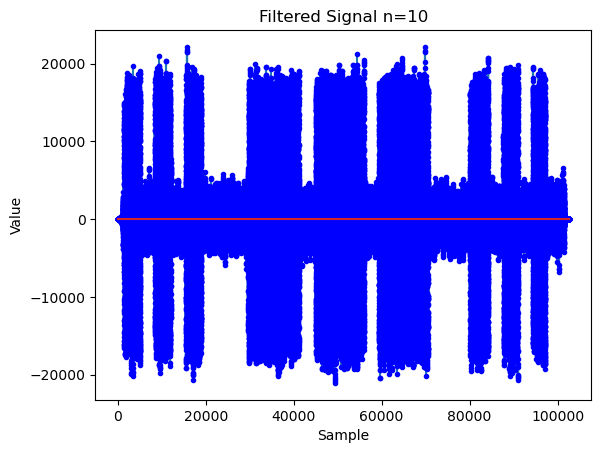

In [12]:
n=10
h= np.ones(n)/n
y = signal.convolve(x,h)

plt.figure()
plt.stem(y,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered Signal n=10')
plt.show()

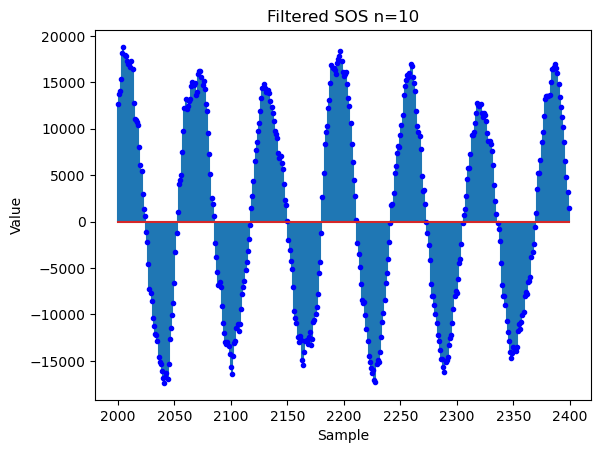

In [13]:
plt.figure()
t = range(2000,2400)
plt.stem(t,y[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered SOS n=10')
plt.show()

In [14]:
ipd.display(ipd.Audio(data=y, rate=fs))

Increasing n has made the noise become fainter in the sound. The sine wave became cleaner, and the amplitudes became more stable throughout the sinusoidal wave.

## 4.5 Limit on the moving window length

There is a practical limit to how large the moving window can be. If \(n\) becomes too large, the filter no longer only removes noise but also starts removing important parts of the signal itself. This causes loss of detail, reduced burst definition, and poorer audio quality. Therefore, the window must be chosen as a compromise: large enough to reduce noise, but not so large that it distorts the Morse code structure.

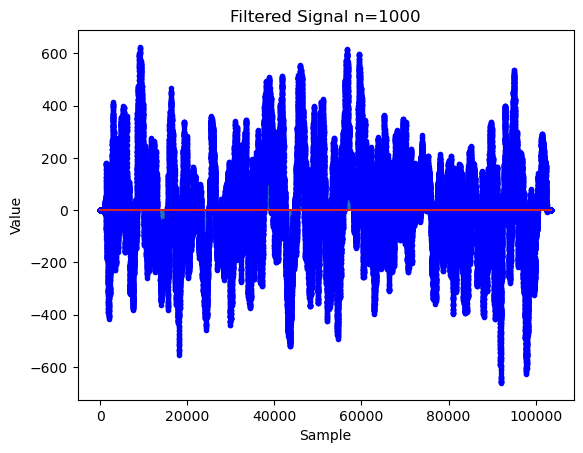

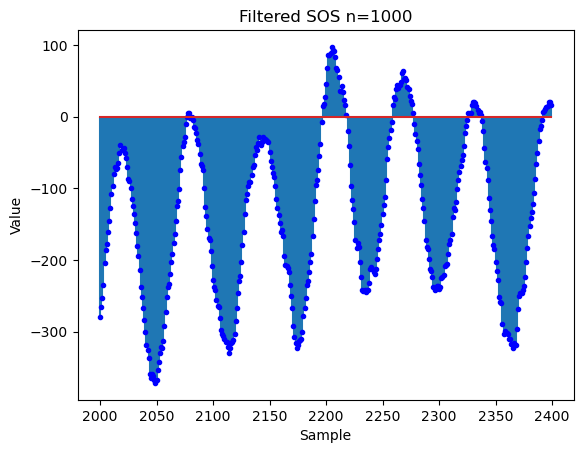

In [15]:
n=1000
h= np.ones(n)/n
y = signal.convolve(x,h)

plt.figure()
plt.stem(y,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered Signal n=1000')
plt.show()

plt.figure()
t = range(2000,2400)
plt.stem(t,y[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered SOS n=1000')
plt.show()

ipd.display(ipd.Audio(data=y, rate=fs))

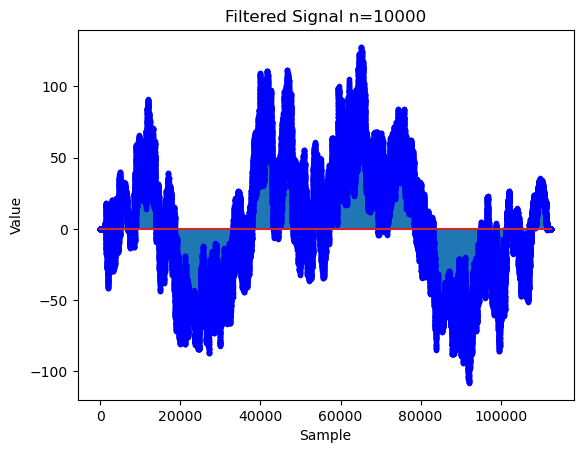

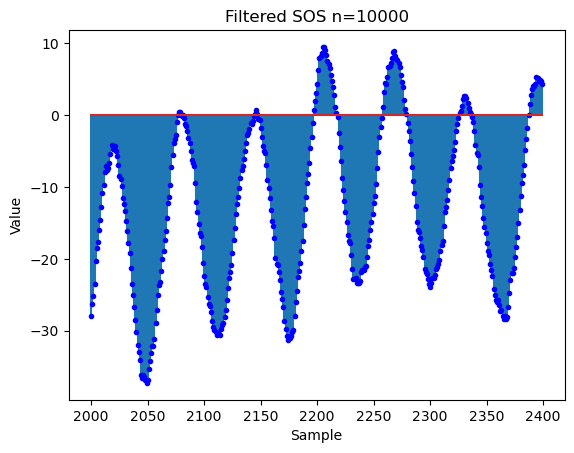

In [16]:
n=10000
h= np.ones(n)/n
y = signal.convolve(x,h)

plt.figure()
plt.stem(y,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered Signal n=10000')
plt.show()

plt.figure()
t = range(2000,2400)
plt.stem(t,y[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered SOS n=10000')
plt.show()

ipd.display(ipd.Audio(data=y, rate=fs))

As n gets larger at first the noise starts to decrease and the sound is clearer. When the number gets too big the graph looses its shape and the sound does not resemble at all the SOS Morse code. 

# 5 Band‐Pass Filter

## 5.1

In [17]:
h = np.load(os.path.join('data','filter.npy'))

## 5.2 Impulse response of the provided filter

The plotted impulse response shows that this filter is more complex than the moving average filter. Unlike the simple constant coefficients of the averaging filter, this impulse response contains varying positive and negative values, which indicates that it is designed to selectively keep a certain frequency range while attenuating others. This is consistent with a band-pass filter, since the Morse tone is concentrated around a specific frequency.

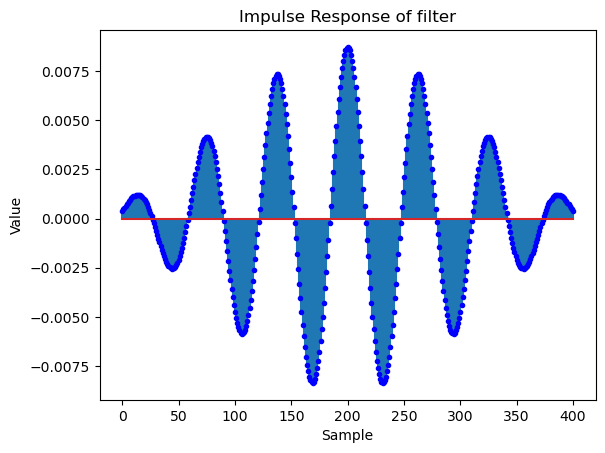

In [18]:
plt.figure()
plt.stem(h,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Impulse Response of filter')
plt.show()

## 5.3 Effect of the band-pass filter

The band-pass filter gives better results than the moving average filter because it is designed to keep the frequency range of the Morse tone while suppressing frequencies outside that band. In the plot, the bursts are clearer and the background fluctuations are reduced more effectively. In audio playback, the Morse tone is more distinct and easier to hear, while much of the unwanted noise is removed. This makes the band-pass filter more suitable for this signal than simple averaging.

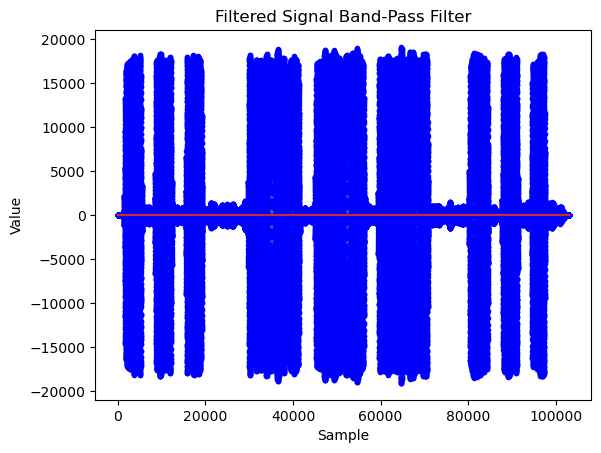

In [19]:
fs, x = wavfile.read(os.path.join('data', 'noisy_sos_cw_700_15_wpm.wav'))
y = signal.convolve(x,h)

plt.figure()
plt.stem(y,markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered Signal Band-Pass Filter')
plt.show()

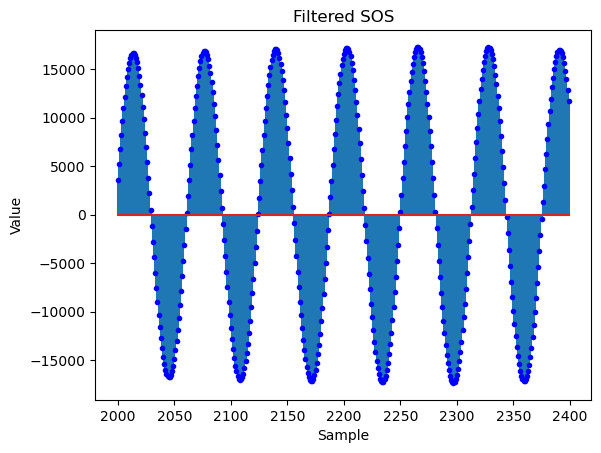

In [20]:
plt.figure()
t = range(2000,2400)
plt.stem(t,y[t],markerfmt='b.')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Filtered SOS')
plt.show()

In [21]:
ipd.display(ipd.Audio(data=y, rate=fs))

This filter removes all the noise when you hear the sound. The Morse code sounds crisp, and also the graph does not have fluctuating amplitudes. The graph for the values between 2000 and 2400 also shows how stable the wave became; the amplitudes are almost identical and there is a smooth line all throughout.